In [85]:
#initialize

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Configuration
k = 10  # Number of clusters / genes

# Load dataset
df = pd.read_excel("C:\\Users\\Diwakar\\Desktop\\Normalized_Mean.xlsx")

# Vectorized scaling (replaces the nested loops)
df = df * 100000


In [86]:
df

,N_Mean,P_Mean
0,30168.446044,46793.407162
1,36524.121838,23858.010041
2,35523.900051,24919.456517
3,33075.508584,47049.473270
4,24829.140330,40630.223190
...,...,...
96,34058.760834,24691.827113
97,31380.335766,22100.119962
98,30760.403948,19363.913859
99,34775.821162,27350.519116


In [87]:
#poulation
population_size = 50                      # no of chromosoms in a population 

population = []                                                              
for i in range(population_size):
    temp={}
    temp['choromosome'] = df.sample(k)         # k is 10  (number of :     centeroids(cluster_centers)   / clusters /   genes_in_a_chromosome )   
    temp['fitness'] = None
    population.append(temp) 
                                                
fittest_population = []
fittest_gen = []
pool_index = [0,1]


In [88]:
def fitness_calc(temp_df):
        dist = temp_df.groupby(['closest_centroid'])[[f'distance_from_{t+1}' for t in range(k)]].sum()

        M = 0
        for y in range(k):
            try:
                M = M + dist.iat[y,y]
            except:
                continue
        fitness = (1/M) * 1000
        return fitness

In [89]:
def kmeans_c():
    for i, choromosome in enumerate(population):                      # itterate each chromosome(50) in population
         # k is 10      (population_size=50)
        
        global cluster_centroids # Ensure changes save back to your main list
        cluster_centroids = choromosome['choromosome']

        temp_df = df.copy()
        
        global col
        data = ['g','r','b','y','c','m','orange','indigo','teal','maroon']
        col = pd.DataFrame(data)

    #assignment
        flag=0
        count=1
        
        

        """Actual KMeans start"""
        while flag==0 and count<=25:

            for centeroid_no in range(k):            
                try:                 # k(0 to 9)
                    temp_df[f'distance_from_{centeroid_no+1}'] = np.sqrt( 
                                                (temp_df['N_Mean'] - cluster_centroids.iloc[centeroid_no,0])**2 + 
                                                (temp_df['P_Mean'] - cluster_centroids.iloc[centeroid_no,1])**2)                        
                except:
                    continue

               
            temp_df['closest_centroid'] = temp_df[[f'distance_from_{u+1}' for u in range(k)]].idxmin(axis=1)
            temp_df['closest_centroid'] = temp_df['closest_centroid'].map(lambda x: int(x.lstrip('distance_from_'))) 
           # temp_df['colour']=temp_df['closest_centroid'].map(lambda x: col.iat[x-1,0])

            
            #update__________________________________________________________________________________________________________
            old_centeroids = cluster_centroids
            cluster_centroids = temp_df.groupby(['closest_centroid'])[['N_Mean','P_Mean']].mean()
        
            
            colmn=temp_df.closest_centroid.unique()
            """If any cluster_centroid is missing add if from old_centeroid """
            for tt in range (1,k+1):    # tt = 1 to 10
                for jj in range(colmn.size):
                    found=0
                    if tt==colmn[jj]:
                        found=1
                    if found==0:
                        try:
                            cluster_centroids.append(old_centeroids.iloc[tt-1])
                        except:
                            continue

            
            # Check if centroids stopped moving
            count+=1
            flag=1
            for q in range(k):
                try:
                    if(cluster_centroids.iat[q,0] != old_centeroids.iat[q,0] or 
                       cluster_centroids.iat[q,1] != old_centeroids.iat[q,1] ):
                          flag=0   # Centroids moved, loop must run again
                          break
                except:
                    continue

        # update the choromosome values in population with the ones calculated with K_Means
        cluster_centroids = cluster_centroids.sort_values(by=['N_Mean']) 
        population[i]['choromosome'] = cluster_centroids
                    
        ####  FITNESS_____________  
        population[i]['fitness']= fitness_calc(temp_df)
        

In [90]:
def selection():  
    global pool_index 
    if population[0]['fitness'] > population[1]['fitness']:
        pool_index=[0,1]      # contains index of the 1st and 2nd, most fittest chromosomes in the population
    else:
        pool_index=[1,0]
        
    for i in range(2,population_size):

        current_fitness = population[i]['fitness']
        best_fitness = population[pool_index[0]]['fitness']
        second_best_fitness = population[pool_index[1]]['fitness']

        # Case A: Current chromosome beats the champion
        if current_fitness > best_fitness: 
            pool_index[1] = pool_index[0]                   # Demote best to second best
            pool_index[0] = i                               # Update absolute best
        #Case B: Current chromosome beats the runner-up
        elif current_fitness > second_best_fitness: 
            pool_index[1] = i  

    fittest_gen.append(population[pool_index[0]])


In [91]:
def crossover():
    crossover_probablity = random.uniform(0,1)      # a random floating-point (decimal) number between 0 and 1, inclusive.

    if crossover_probablity < 0.8:
        cut_point = random.randint(0,k-1)         # Possible outcomes: 1 to 10
                                                                                 
        champ1 = population[pool_index[0]]['choromosome'].copy()            
        champ2 = population[pool_index[1]]['choromosome'].copy()          
     
        for z in range(cut_point, cut_point+3 ):         # swap 3 genes starting from cut_point                          
            if z<k:
                temp = champ1.iloc[z].copy()
                champ1.iloc[z]= champ2.iloc[z]
                champ2.iloc[z]=temp
       

        """Prevent a child chromosome from having two identical cluster centers."""
        champ1 = champ1.drop_duplicates(keep=False)       # The function uses (keep=False) to
        champ2 = champ2.drop_duplicates(keep=False)         #find any identical duplicate rows and completely delete them to keep clusters unique

       
        """if both children managed to maintain exactly 10 unique centroids, 
           only then will we overwrite the old parents in the population array 
           with the new child chromosomes. '"""
        if (champ1.shape[0]==k and champ2.shape[0]==k):
            population[pool_index[0]]['choromosome'] = champ1.sort_values(by=['N_Mean'])
            population[pool_index[1]]['choromosome'] = champ2.sort_values(by=['N_Mean'])
        
       

In [92]:
def mutation():
    mutation_probablity = random.uniform(0,1)

    if mutation_probablity<=0.1 :
        mutate_choromosome = random.randint(0,population_size-1)
        mutate_gene = random.randint(0,k-1)
        b = random.random()* 10000
        print(b)

        champ1 = population[mutate_choromosome]['choromosome']      
        champ1_gene = champ1.iloc[mutate_gene]


        if champ1_gene['N_Mean'] != 0:
            op = random.randint(0,1)
            if op==0:
                champ1_gene['N_Mean'] = champ1_gene['N_Mean'] + 2*b*champ1_gene['N_Mean'] 
                champ1_gene['P_Mean'] = champ1_gene['P_Mean'] + 2*b*champ1_gene['P_Mean']
            else:
                champ1_gene['N_Mean'] = abs(champ1_gene['N_Mean'] - 2*b*champ1_gene['N_Mean'] )
                champ1_gene['P_Mean'] = abs(champ1_gene['P_Mean'] - 2*b*champ1_gene['P_Mean'])
        else:
            if op==0:
                champ1_gene['N_Mean'] = champ1_gene['N_Mean'] + 2*b 
                champ1_gene['P_Mean'] = champ1_gene['P_Mean'] + 2*b 
            else:
                champ1_gene['N_Mean'] = abs(champ1_gene['N_Mean'] - 2*b)
                champ1_gene['P_Mean'] = abs(champ1_gene['P_Mean'] - 2*b)
      

In [93]:
gen_size=50   
kmeans_c()
for m in range(gen_size):
    selection()
    crossover()
    mutation()
    kmeans_c()

6724.061806135945
6543.3169082931145
8516.430980759122
4363.774003539534
6204.443605988527
1141.5702348828981
7472.442020441261
5787.453584121832
15.673985441033711
96.86739540857303
4256.669175332601
3548.3252258774855
158.91527223096946


In [94]:
for vt in fittest_gen:
    fittest_population.append(vt['fitness'])

In [95]:
print("maximum fittness : ")
print(max(fittest_population))
print(max(fittest_population)*100000)

maximum fittness : 
0.004044055651206513
404.40556512065126


Text(0, 0.5, 'Fitness')

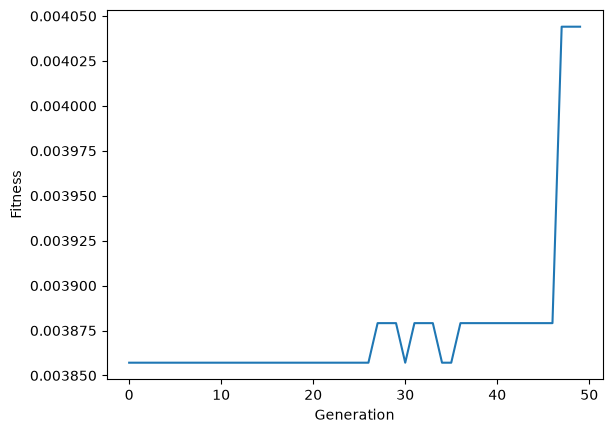

In [96]:
plt.plot(fittest_population)
plt.xlabel('Generation')
plt.ylabel('Fitness')

Text(0, 0.5, 'PD reading')

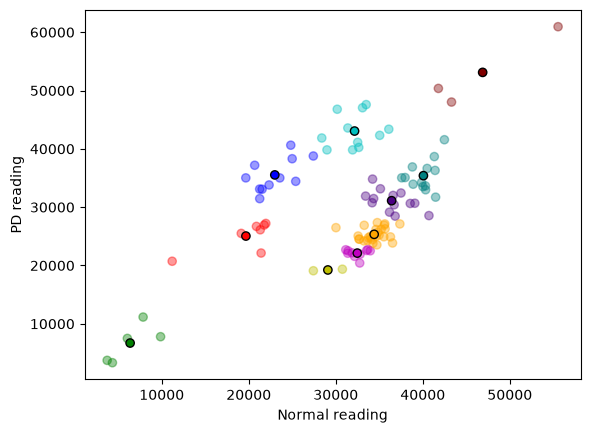

In [97]:
crr=fittest_gen[2]['choromosome']
for j in range(k):
    df['dist_from_{}'.format(j+1)]= (np.sqrt((df['N_Mean']-crr.iloc[j,0])**2 + (df['P_Mean']-crr.iloc[j,1])**2))

df['closest']=df[['dist_from_{}'.format(u+1) for u in range(k)]].idxmin(axis=1)
df['closest']=df['closest'].map(lambda x: int(x.lstrip('dist_from_')))
df['colour']=df['closest'].map(lambda x: col.iat[x-1,0])
plt.scatter(df['N_Mean'],df['P_Mean'],color=df['colour'],alpha=0.4)
for i in range(k):
     try:
        plt.scatter(crr['N_Mean'],crr['P_Mean'], color=col[i],edgecolor='k')
     except:
        continue
    
plt.xlabel('Normal reading')
plt.ylabel('PD reading')